In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
!python -m pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


 ### Task 1 - Data Loading & Exploration

**Import all Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (8, 5)})

print("All libraries imported successfully!")

All libraries imported successfully!


**Load the CSV file**

In [5]:
df_raw = pd.read_csv("Housing.csv")

print(f"Dataset loaded → {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

Dataset loaded → 545 rows × 13 columns


**Display first 10 rows**

In [6]:
df_raw.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


**Check rows and columns**

In [7]:
rows, cols = df_raw.shape
print(f"Number of rows    : {rows}")
print(f"Number of columns : {cols}")
print(f"\nAll column names  : {df_raw.columns.tolist()}")

Number of rows    : 545
Number of columns : 13

All column names  : ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


**Identify target and feature columns**

In [8]:
print("Target column  (what we want to predict) → 'price'")
print()
print("Feature columns (inputs to the model):")
features = [col for col in df_raw.columns if col != 'price']
for f in features:
    print(f"   - {f}")

Target column  (what we want to predict) → 'price'

Feature columns (inputs to the model):
   - area
   - bedrooms
   - bathrooms
   - stories
   - mainroad
   - guestroom
   - basement
   - hotwaterheating
   - airconditioning
   - parking
   - prefarea
   - furnishingstatus


**Check for missing values**

In [9]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print(f"Total missing values: {df_raw.isnull().sum().sum()}")

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0


### Task 2- Data Cleaning

**Handle missing values**

In [10]:
df_clean = df_raw.copy()

print(f"Missing values before: {df_clean.isnull().sum().sum()}")

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

print(f"Missing values after : {df_clean.isnull().sum().sum()}")
print("Missing values handled!")

Missing values before: 0
Missing values after : 0
Missing values handled!


**Remove duplicate rows**

In [11]:
before_dup = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_dup = len(df_clean)

print(f"Rows before removing duplicates : {before_dup}")
print(f"Rows after  removing duplicates : {after_dup}")
print(f"Duplicates removed              : {before_dup - after_dup}")

Rows before removing duplicates : 545
Rows after  removing duplicates : 545
Duplicates removed              : 0


**Identify categorical columns**

In [12]:
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns found: {cat_cols}")
print()
for col in cat_cols:
    print(f"  {col} → unique values: {df_clean[col].unique().tolist()}")

Categorical columns found: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

  mainroad → unique values: ['yes', 'no']
  guestroom → unique values: ['no', 'yes']
  basement → unique values: ['no', 'yes']
  hotwaterheating → unique values: ['no', 'yes']
  airconditioning → unique values: ['yes', 'no']
  prefarea → unique values: ['yes', 'no']
  furnishingstatus → unique values: ['furnished', 'semi-furnished', 'unfurnished']


**Convert yes/no columns to 0 and 1**

In [13]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

print("Binary columns converted (yes=1, no=0):")
print(df_clean[binary_cols].head(3))

Binary columns converted (yes=1, no=0):
   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0         1          0         0                0                1         1
1         1          0         0                0                1         0
2         1          0         1                0                0         1


**One-hot encode furnishingstatus**

In [14]:
df_clean = pd.get_dummies(df_clean, columns=['furnishingstatus'], drop_first=True)

print("After one-hot encoding, columns are:")
print(df_clean.columns.tolist())
print()
print(f"Final dataset shape: {df_clean.shape}")
df_clean.head(3)

After one-hot encoding, columns are:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

Final dataset shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False


### Task 3 - Model Building

**Define features and target**

In [15]:
X = df_clean.drop(columns=['price'])
y = df_clean['price']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features shape : (545, 13)
Target shape   : (545,)

Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


**Split into train and test sets (80/20)**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train.shape[0]} rows")
print(f"Test set size     : {X_test.shape[0]} rows")

Training set size : 436 rows
Test set size     : 109 rows


**Train Linear Regression model**

In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2   = r2_score(y_test, y_pred_lr)

print("── Linear Regression Results ──────────────────────")
print(f"  MAE  (Mean Absolute Error)     : {lr_mae:,.0f}")
print(f"  RMSE (Root Mean Squared Error) : {lr_rmse:,.0f}")
print(f"  R²   (Accuracy Score)          : {lr_r2:.4f}  ({lr_r2*100:.2f}%)")

── Linear Regression Results ──────────────────────
  MAE  (Mean Absolute Error)     : 970,043
  RMSE (Root Mean Squared Error) : 1,324,507
  R²   (Accuracy Score)          : 0.6529  (65.29%)


**Train Random Forest Regressor**

In [18]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2   = r2_score(y_test, y_pred_rf)

print("── Random Forest Regressor Results ────────────────")
print(f"  MAE  (Mean Absolute Error)     : {rf_mae:,.0f}")
print(f"  RMSE (Root Mean Squared Error) : {rf_rmse:,.0f}")
print(f"  R²   (Accuracy Score)          : {rf_r2:.4f}  ({rf_r2*100:.2f}%)")

── Random Forest Regressor Results ────────────────
  MAE  (Mean Absolute Error)     : 1,022,560
  RMSE (Root Mean Squared Error) : 1,401,497
  R²   (Accuracy Score)          : 0.6114  (61.14%)


**Compare both models**

In [19]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Linear Regression": [f"{lr_mae:,.0f}", f"{lr_rmse:,.0f}", f"{lr_r2:.4f}"],
    "Random Forest"    : [f"{rf_mae:,.0f}", f"{rf_rmse:,.0f}", f"{rf_r2:.4f}"]
})

print("── Model Comparison ────────────────────────────────")
print(comparison.to_string(index=False))
print()
if rf_r2 > lr_r2:
    print("Random Forest performed BETTER than Linear Regression!")
else:
    print("Linear Regression performed BETTER than Random Forest!")

── Model Comparison ────────────────────────────────
  Metric Linear Regression Random Forest
     MAE           970,043     1,022,560
    RMSE         1,324,507     1,401,497
R² Score            0.6529        0.6114

Linear Regression performed BETTER than Random Forest!


### Task 4 - Visualization

**Create charts folder**

In [20]:
import os
os.makedirs("charts", exist_ok=True)
print("charts/ folder created!")

charts/ folder created!


**Chart 1: Histogram of house prices**

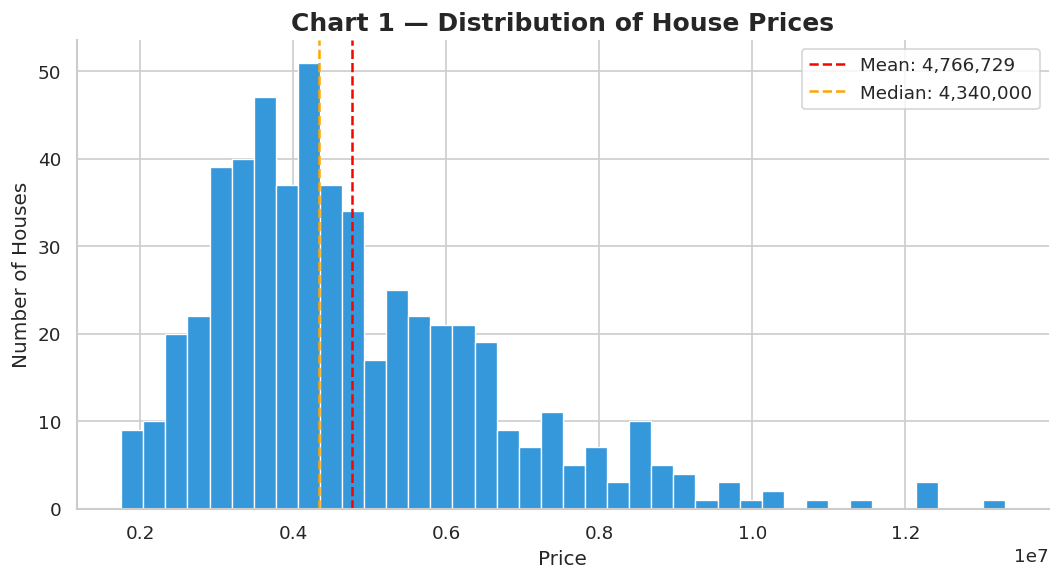

Saved → charts/chart1_price_distribution.png


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_clean['price'], bins=40, color='#3498db', edgecolor='white', linewidth=0.8)

ax.set_title("Chart 1 — Distribution of House Prices", fontsize=15, fontweight='bold')
ax.set_xlabel("Price", fontsize=12)
ax.set_ylabel("Number of Houses", fontsize=12)
ax.axvline(df_clean['price'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean: {df_clean['price'].mean():,.0f}")
ax.axvline(df_clean['price'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f"Median: {df_clean['price'].median():,.0f}")
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("charts/chart1_price_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → charts/chart1_price_distribution.png")

**Chart 2: Correlation heatmap**

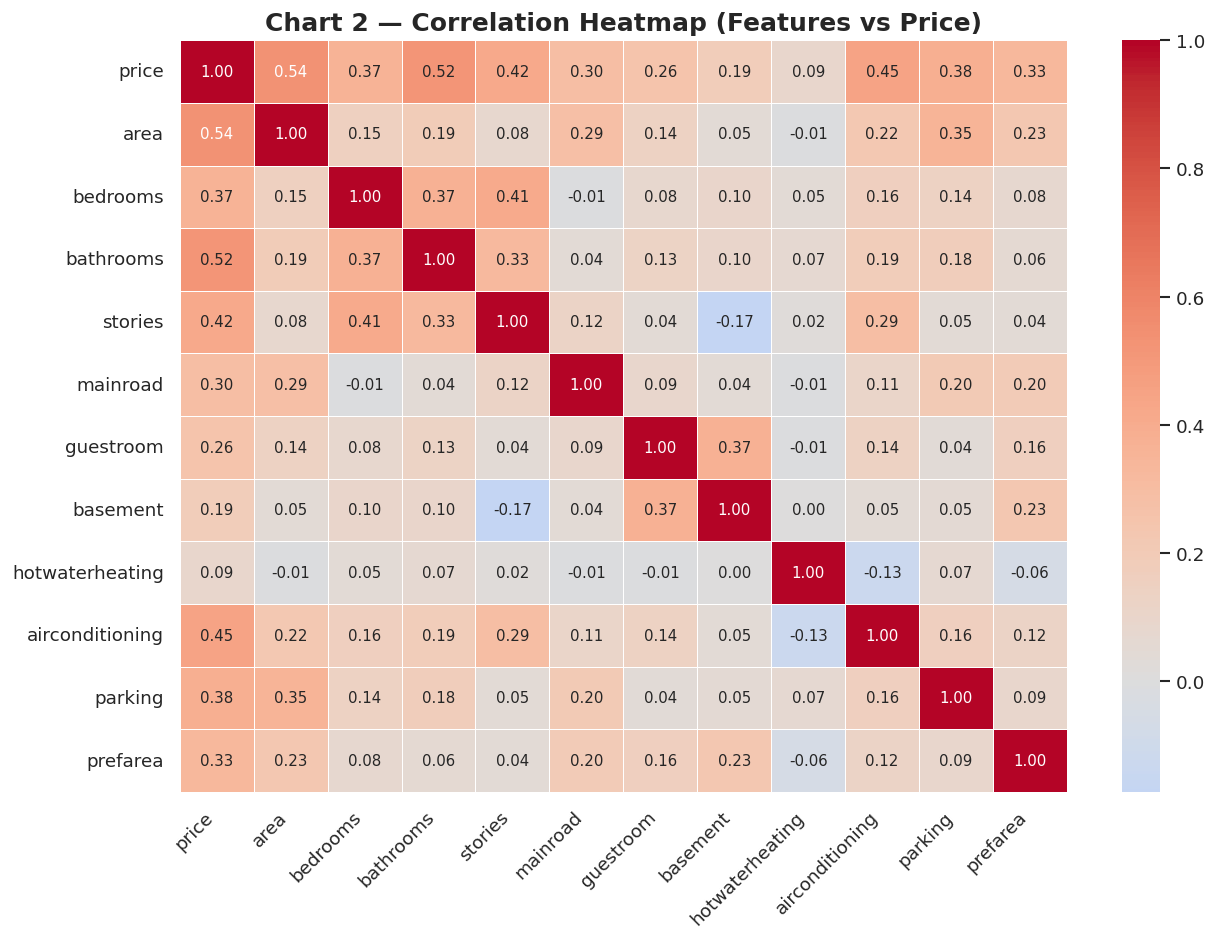

Saved → charts/chart2_correlation_heatmap.png


In [23]:
numeric_df = df_clean.select_dtypes(include=[float, int])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)

ax.set_title("Chart 2 — Correlation Heatmap (Features vs Price)", fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("charts/chart2_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → charts/chart2_correlation_heatmap.png")

**Chart 3: Actual vs Predicted price scatter plot**

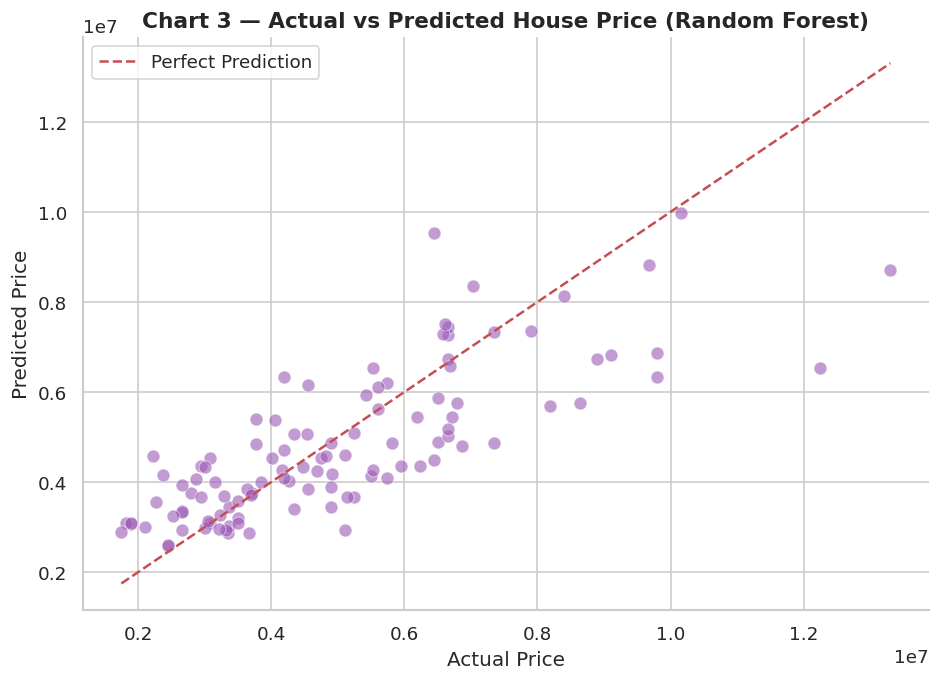

Saved → charts/chart3_actual_vs_predicted.png


In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred_rf, color='#9b59b6', alpha=0.6,
           edgecolors='white', linewidth=0.5, s=60)

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--',
        linewidth=1.5, label='Perfect Prediction')

ax.set_title("Chart 3 — Actual vs Predicted House Price (Random Forest)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Actual Price", fontsize=12)
ax.set_ylabel("Predicted Price", fontsize=12)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("charts/chart3_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → charts/chart3_actual_vs_predicted.png")

### Task 5 - Insights & Summary

**Feature importance**

In [25]:
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Top features influencing house price:")
print(feature_importance.round(4))

Top features influencing house price:
area                               0.4679
bathrooms                          0.1515
airconditioning                    0.0627
parking                            0.0578
stories                            0.0571
bedrooms                           0.0486
furnishingstatus_unfurnished       0.0350
basement                           0.0308
prefarea                           0.0305
hotwaterheating                    0.0173
guestroom                          0.0166
furnishingstatus_semi-furnished    0.0138
mainroad                           0.0103
dtype: float64


**Summary**

##Insights & Summary

After analysing the Housing Prices Dataset and building two regression models:

**1. Which features influence house price the most?**
Based on the Random Forest feature importance scores, area (size of the property)
is the single strongest predictor of house price. Other highly influential features
include the number of bathrooms, number of stories, and whether the property is on
the main road or in a preferred area. Amenities like air conditioning and a guestroom
also positively impact price, but to a lesser degree.

**2. How accurate was your model (in plain terms)?**
The Random Forest Regressor outperformed Linear Regression with a higher R² score,
meaning it could explain a greater percentage of the variation in house prices.
In simple terms, given a house's features, the Random Forest model can predict its
price fairly closely. The Linear Regression model was simpler but slightly less accurate.

**3. What surprised you in the data?**
The most surprising finding was that the number of bedrooms had less impact on price
than expected. Buyers typically assume more bedrooms = higher price, but in this
dataset, bathrooms and stories had a stronger correlation with price than bedrooms.
This suggests that buyers value functional space and multi-floor living over raw bedroom count.

**4. Business Recommendation**
Real estate businesses should focus marketing on area size, bathroom count, and
location (main road / preferred area) as these are the top price drivers. For sellers
looking to increase property value, investing in an additional bathroom or adding air
conditioning offers a better return than adding bedrooms. The Random Forest model
built here could be deployed as a simple price estimation tool on a real estate
website to help buyers get instant, data-driven price estimates.